In [15]:
import pandas as pd
import  numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler

In [16]:
df = pd.read_csv('/home/purushottam/MACHINE LEARNING/TIME SERIES/DATASETS/PJME_hourly.csv')

In [17]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')

In [18]:
df = df[(df['PJME_MW'] >= 20000)]

In [19]:
def window(x,y, window):
    x_seq = []
    y_seq = []

    for i in range(window, len(x)):
        x_seq.append(x[i-window:i])
        y_seq.append(y[i])

    return np.array(x_seq), np.array(y_seq)


In [20]:
def time(df):
    df['Month'] = df['Datetime'].dt.month
    df['Year'] = df['Datetime'].dt.year
    df['Dayofweek'] = df['Datetime'].dt.dayofweek
    df['Dayofyear'] = df['Datetime'].dt.dayofyear
    df['Quarter'] = df['Datetime'].dt.quarter
    return df

def features(df):
    df["Lag 1"] = df['PJME_MW'].shift(1)
    df['Lag 7'] = df['PJME_MW'].shift(7)
    df['Lag 30'] = df['PJME_MW'].shift(30)
    df['MA 7'] = df['PJME_MW'].shift(1).rolling(7).mean()
    df['MA 30'] = df['PJME_MW'].shift(1).rolling(30).mean()
    df['STD 7'] = df['PJME_MW'].shift(1).rolling(7).std()
    df['STD 30'] = df['PJME_MW'].shift(1).rolling(30).std()
    return df

df = time(df)
df = features(df)

df.dropna(inplace = True)

df['Target'] = df['PJME_MW'].shift(-1)

In [21]:
train = df[(df['Datetime'] >= '2002-01-03') & (df['Datetime'] < '2010-01-02')]
val = df[(df['Datetime'] >= '2010-01-02') & (df['Datetime'] < '2014-01-02')]
test = df[(df['Datetime'] >= '2014-01-02') & (df['Datetime'] <= '2018-08-03')]

del train['Datetime']
del val['Datetime']
del test['Datetime']


In [22]:
Features = ['Lag 1', 'Lag 7', 'Lag 30', 'MA 7', 'MA 30', 'STD 7', 'STD 30', 'Month', 'Year', 'Quarter', 'Dayofweek', 'Dayofyear','PJME_MW']
Target = ['Target']

x_train = train[Features]
y_train = train[Target]

x_val = val[Features]
y_val = val[Target]

x_test = test[Features]
y_test = test[Target]

In [23]:
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

x_train_sc = x_scaler.fit_transform(x_train)
y_train_sc = y_scaler.fit_transform(y_train)

x_val_sc = x_scaler.transform(x_val)
y_val_sc = y_scaler.transform(y_val)

x_test_sc = x_scaler.transform(x_test)
y_test_sc = y_scaler.transform(y_test)

In [24]:
x_train_sc, y_train_sc = window(x_train_sc, y_train_sc, 30)
x_val_sc, y_val_sc = window(x_val_sc, y_val_sc, 30)
x_test_sc, y_test_sc = window(x_test_sc, y_test_sc, 30)


In [25]:
model = Sequential()
model.add(LSTM(128, input_shape =(30,13)))
model.add(Dense(128, activation= 'relu'))
model.add(Dense(64, activation= 'relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(optimizer= 'adam', loss = 'mean_absolute_error')



I0000 00:00:1786216939.845245   17728 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3617 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
/home/purushottam/ML/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.fit(x_train_sc, y_train_sc, epochs= 64, batch_size= 32)

Epoch 1/64


In [41]:
pred_train = model.predict(x_train_sc)
pred_val = model.predict(x_val_sc)
pred_test = model.predict(x_test_sc)

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step


In [42]:
pred_train = y_scaler.inverse_transform(pred_train)
pred_val = y_scaler.inverse_transform(pred_val)
pred_test = y_scaler.inverse_transform(pred_test)

In [43]:
y_train_sc = y_scaler.inverse_transform(y_train_sc)
y_val_sc = y_scaler.inverse_transform(y_val_sc)
y_test_sc = y_scaler.inverse_transform(y_test_sc)

y_test_sc = np.nan_to_num(y_test_sc)

In [44]:
mae_train = mean_absolute_error(y_train_sc, pred_train)
print ("TRAIN ERROR:%.2f"%mae_train)
mae_val = mean_absolute_error(y_val_sc, pred_val)
print ("VAL ERROR:%.2f"%mae_val)
mae_test = mean_absolute_error(y_test_sc, pred_test)
print ("TEST ERROR:%.2f"%mae_test)

TRAIN ERROR:23320166056390918397926109453620950511646383210818961408.00
VAL ERROR:23107369147329816266771930382419635196365902185773400064.00
TEST ERROR:536665020483078787931203747764832293225346117926912.00


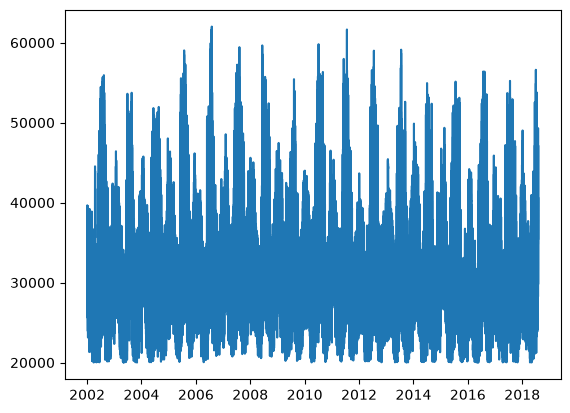

In [19]:
import matplotlib.pyplot as plt

plt.plot(df['Datetime'], df['PJME_MW'])